### ***1. Importing Libraries***

In [1]:
import os
from Bio import SeqIO
from glob import glob
from Bio.Data import CodonTable
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
import pandas as pd


### ***2. Loading The DATASET***

In [2]:

# add ".." because jupyter notebook works in the current directory only
# ".." causes it to go back to one directory
rscu_avg_gyrA = pd.read_csv(os.path.join("..","results","CSVs","rscu_avg_gyrA.csv"),index_col=0)
rscu_avg_katG = pd.read_csv(os.path.join("..","results","CSVs","rscu_avg_katG.csv"),index_col=0)
rscu_avg_rpoB = pd.read_csv(os.path.join("..","results","CSVs","rscu_avg_rpoB.csv"),index_col=0)
rscu_all_samples = pd.read_csv(os.path.join("..","results","CSVs","rscu_all_samples.csv"))
enc_gc3_all_samples = pd.read_csv(os.path.join("..","results","CSVs","enc_gc3_all_samples.csv"))

#### *2.1 Checking the datasets*

In [3]:
# Shape
print("rscu_avg_gyrA:",rscu_avg_gyrA.shape)
print("rscu_avg_katG:",rscu_avg_katG.shape)
print("rscu_avg_rpoB:",rscu_avg_rpoB.shape)
print("rscu_all_samples:",rscu_all_samples.shape)
print("enc_gc3_all_samples:",enc_gc3_all_samples.shape)

rscu_avg_gyrA: (61, 2)
rscu_avg_katG: (61, 2)
rscu_avg_rpoB: (58, 2)
rscu_all_samples: (17579, 5)
enc_gc3_all_samples: (100, 8)


In [4]:
# Type of datatype
print("rscu_avg_gyrA:\n",rscu_avg_gyrA.dtypes)
# print("\nrscu_avg_katG:\n",rscu_avg_katG.dtypes)
# print("\nrscu_avg_rpoB:\n",rscu_avg_rpoB.dtypes)
print("\nrscu_all_samples:\n",rscu_all_samples.dtypes)
print("\nenc_gc3_all_samples:\n",enc_gc3_all_samples.dtypes)

rscu_avg_gyrA:
 Sensitive    float64
Resistant    float64
dtype: object

rscu_all_samples:
 Sample_Id     object
Group         object
Gene          object
Codon         object
RSCU         float64
dtype: object

enc_gc3_all_samples:
 Sample_ID     object
Group         object
enc_rpoB     float64
gc3_rpoB     float64
enc_katG     float64
gc3_katG     float64
enc_gyrA     float64
gc3_gyrA     float64
dtype: object


# ***3. PLOTS***

In [5]:
# x = rscu_avg_rpoB["Sensitive"]
# y = rscu_avg_rpoB["Resistant"]

# max_val = max(x.max(),y.max())
# plt.figure(figsize=(7,5))
# plt.plot([0,max_val],[0,max_val],color="crimson", linestyle="--", label="y = x")
# plt.scatter(x,y,color="royalblue", alpha=0.7)
# plt.xlabel("Sensitive RSCU")
# plt.ylabel("Resistant RSCU")
# plt.title("RSCU: Sensitive vs Resistant (rpoB)")
# plt.xlim(0, max_val)
# plt.ylim(0, max_val)
# plt.show()


#### ***3.1 RSCU Scatter Plots***

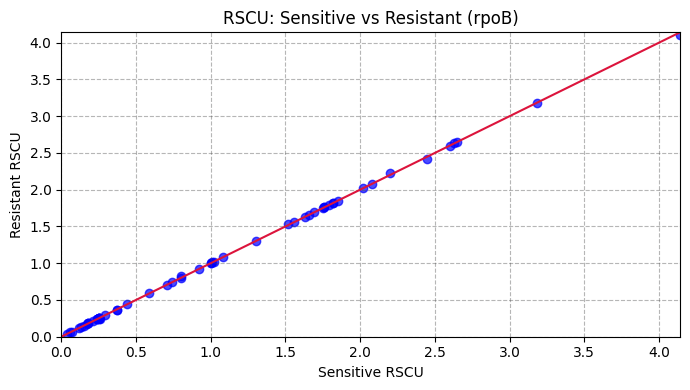

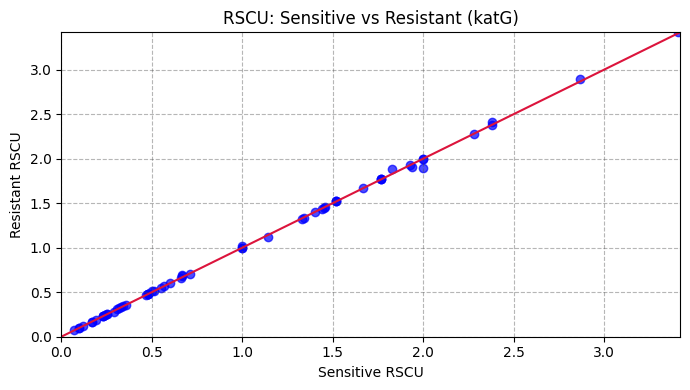

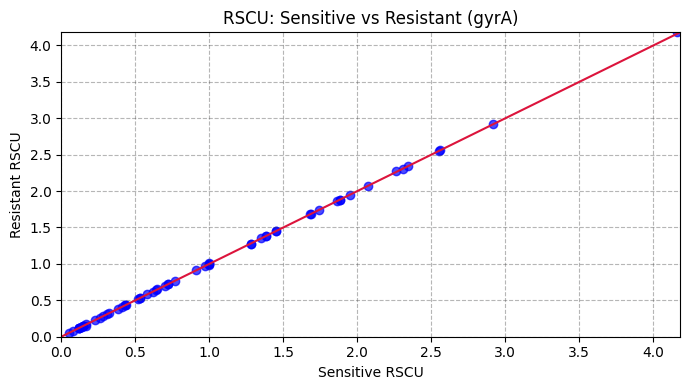

In [6]:
data = [
    ("rpoB",rscu_avg_rpoB),
    ("katG",rscu_avg_katG),
    ("gyrA",rscu_avg_gyrA)
]

for gene,dataset in data:
    x = dataset["Sensitive"]
    y = dataset["Resistant"]
    plt.figure(figsize=(7,4))
    max_val = max(x.max(),y.max())
    plt.plot([0,max_val],[0,max_val],color="crimson", linestyle="-", label="y = x")
    plt.scatter(x,y,color="blue", alpha=0.7)
    plt.xlabel("Sensitive RSCU")
    plt.ylabel("Resistant RSCU")
    plt.title(f"RSCU: Sensitive vs Resistant ({gene})")
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    plt.tight_layout()
    plt.savefig(os.path.join("..","results","plots",f"rscu_scatter_{gene}.png"),dpi=300,bbox_inches="tight")
    plt.show()

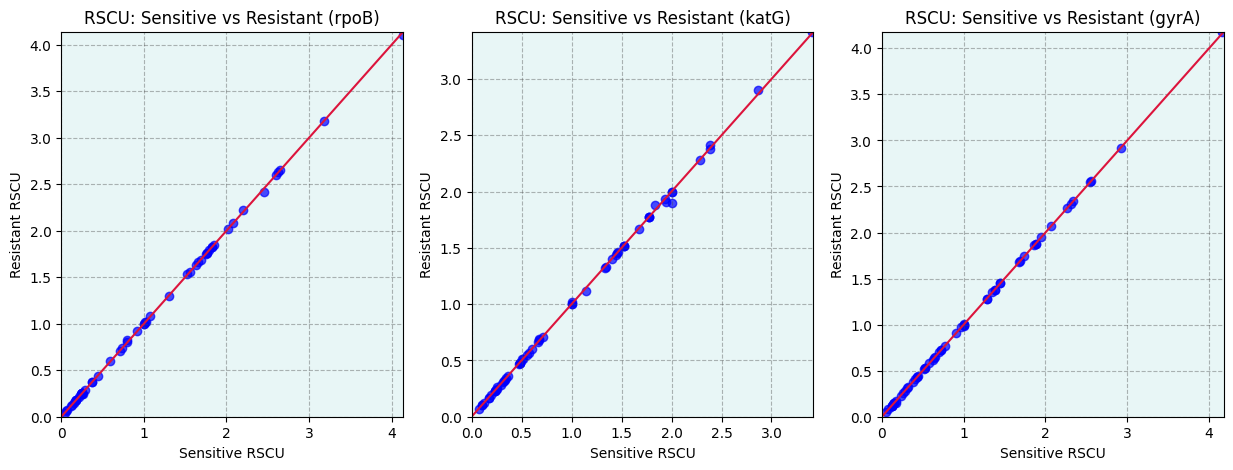

In [7]:
fig, axes  = plt.subplots(1,3,figsize=(15,5))

data = [
    ("rpoB",rscu_avg_rpoB),
    ("katG",rscu_avg_katG),
    ("gyrA",rscu_avg_gyrA)
]

for i, (gene,dataset) in enumerate(data):
    x = dataset["Sensitive"]
    y = dataset["Resistant"]
    ax = axes[i]
    max_val = max(x.max(),y.max())
    ax.plot([0,max_val],[0,max_val],color="crimson", linestyle="-", label="y = x")
    ax.scatter(x,y,color="blue", alpha=0.7)
    ax.set_xlabel("Sensitive RSCU")
    ax.set_ylabel("Resistant RSCU")
    ax.set_title(f"RSCU: Sensitive vs Resistant ({gene})")
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    ax.set_facecolor("#e8f6f6")
plt.savefig(os.path.join("..","results","plots","rscu_scatter_all.png"),dpi=300,bbox_inches="tight")
plt.show()

# ***RSCU EVALUATIONS***

In [16]:
rscu_avg_rpoB["Difference"] = rscu_avg_rpoB["Resistant"] - rscu_avg_rpoB["Sensitive"]
rscu_avg_rpoB["Absolute_Difference"] = rscu_avg_rpoB["Difference"].abs()
rscu_avg_rpoB["Percent_Change"] = ((rscu_avg_rpoB["Resistant"] - rscu_avg_rpoB["Sensitive"]) / rscu_avg_rpoB["Sensitive"])*100
rscu_avg_rpoB.sort_values("Absolute_Difference",ascending=False).head(20)



,Sensitive,Resistant,Difference,Absolute_Difference,Percent_Change
TCG,2.45,2.42,-0.03,0.03,-1.224490
TTG,0.80,0.83,0.03,0.03,3.750000
CTG,4.14,4.11,-0.03,0.03,-0.724638
GCT,0.26,0.24,-0.02,0.02,-7.692308
GCC,2.20,2.22,0.02,0.02,0.909091
AGC,1.01,1.02,0.01,0.01,0.990099
AGT,0.59,0.60,0.01,0.01,1.694915
TCT,0.25,0.26,0.01,0.01,4.000000
CTT,0.25,0.24,-0.01,0.01,-4.000000
TCC,1.52,1.53,0.01,0.01,0.657895


In [17]:
rscu_avg_katG["Difference"] = rscu_avg_katG["Resistant"] - rscu_avg_katG["Sensitive"]
rscu_avg_katG["Absolute_Difference"] = rscu_avg_katG["Difference"].abs()
rscu_avg_katG["Percent_Change"] = ((rscu_avg_katG["Resistant"] - rscu_avg_katG["Sensitive"]) / rscu_avg_katG["Sensitive"])*100
rscu_avg_katG.sort_values("Absolute_Difference",ascending=False).head(20)

,Sensitive,Resistant,Difference,Absolute_Difference,Percent_Change
AGC,2.00,1.90,-0.10,0.10,-5.000000
TCG,1.83,1.88,0.05,0.05,2.732240
ACC,2.38,2.41,0.03,0.03,1.260504
CGG,1.94,1.91,-0.03,0.03,-1.546392
CGC,2.87,2.90,0.03,0.03,1.045296
TCC,1.00,1.02,0.02,0.02,2.000000
TCA,0.67,0.69,0.02,0.02,2.985075
ACG,1.14,1.12,-0.02,0.02,-1.754386
AGT,0.50,0.51,0.01,0.01,2.000000
CTC,1.34,1.33,-0.01,0.01,-0.746269


In [20]:
rscu_avg_gyrA["Difference"] = rscu_avg_gyrA["Resistant"] - rscu_avg_gyrA["Sensitive"]
rscu_avg_gyrA["Absolute_Difference"] = rscu_avg_gyrA["Difference"].abs()
rscu_avg_gyrA["Percent_Change"] = ((rscu_avg_gyrA["Resistant"] - rscu_avg_gyrA["Sensitive"]) / rscu_avg_gyrA["Sensitive"])*100
rscu_avg_gyrA.sort_values("Absolute_Difference",ascending=False).head(10)

,Sensitive,Resistant,Difference,Absolute_Difference,Percent_Change
CTA,0.17,0.15,-0.02,0.02,-11.764706
CTG,4.16,4.18,0.02,0.02,0.480769
GGC,2.26,2.27,0.01,0.01,0.442478
TGT,1.00,0.99,-0.01,0.01,-1.000000
TGC,1.00,1.01,0.01,0.01,1.000000
CAG,1.88,1.88,0.00,0.00,0.000000
AGC,1.38,1.38,0.00,0.00,0.000000
AAA,0.72,0.72,0.00,0.00,0.000000
ACA,0.26,0.26,0.00,0.00,0.000000
GCA,0.43,0.43,0.00,0.00,0.000000
